# Feature Exploration & Analysis

This notebook provides comprehensive analysis of the engineered features for the RL Portfolio Management system.

## Objectives:
1. Load and inspect feature distributions
2. Analyze temporal patterns and stationarity
3. Check for multicollinearity
4. Visualize feature importance
5. Validate no data leakage
6. Compare train vs test distributions

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import normaltest, jarque_bera
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Import your modules
from data_eng import create_features_optimized
from config import *

# Load raw data
raw_prices = pd.read_csv(RAW_DATA_TRAIN_FILE, index_col=0, parse_dates=True)
test_data = pd.read_csv(TEST_SET_FILE, index_col=0, parse_dates=True)

print(f"Raw prices shape: {raw_prices.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"\nTickers: {TICKERS}")
print(f"Macro indicators: {list(MACRO_SYMBOLS.keys())}")


Raw prices shape: (495, 19)
Test data shape: (123, 20)

Tickers: ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
Macro indicators: ['vix', 'dxy', 'oil', 'tnx', 'irx']


In [3]:
# Create features for train and test sets
print("Creating features for training set...")
# Extract prices and volumes from raw data
price_cols = [c for c in raw_prices.columns if '_volume' not in c]
volume_cols = [c.replace('_volume', '') for c in raw_prices.columns if '_volume' in c and c.replace('_volume', '') in price_cols]
train_prices = raw_prices[price_cols]
train_volumes = raw_prices[[c+'_volume' for c in volume_cols]]
train_volumes.columns = volume_cols

train_features = create_features_optimized(train_prices, train_volumes, tickers=TICKERS)

print("\nCreating features for test set...")
# Extract prices and volumes from test data
test_price_cols = [c for c in test_data.columns if '_volume' not in c]
test_volume_cols = [c.replace('_volume', '') for c in test_data.columns if '_volume' in c and c.replace('_volume', '') in test_price_cols]
test_prices = test_data[test_price_cols]
test_volumes = test_data[[c+'_volume' for c in test_volume_cols]]
test_volumes.columns = test_volume_cols

test_features = create_features_optimized(test_prices, test_volumes, tickers=TICKERS)

print(f"\nTrain features shape: {train_features.shape}")
print(f"Test features shape: {test_features.shape}")
print(f"Number of features: {train_features.shape[1]}")


Creating features for training set...
Creating optimized features with volume signals...
Optimized features shape: (443, 83)

Creating features for test set...
Creating optimized features with volume signals...
Optimized features shape: (71, 83)

Train features shape: (443, 83)
Test features shape: (71, 83)
Number of features: 83


## 2. Feature Overview

In [4]:
# Categorize features by type
feature_categories = {
    'returns': [col for col in train_features.columns if 'ret' in col],
    'momentum': [col for col in train_features.columns if 'mom' in col],
    'volatility': [col for col in train_features.columns if 'vol' in col],
    'technical': [col for col in train_features.columns if any(x in col for x in ['rsi', 'macd', 'bb'])],
    'moving_avg': [col for col in train_features.columns if any(x in col for x in ['sma', 'ema'])],
    'drawdown': [col for col in train_features.columns if 'dd' in col],
    'macro': [col for col in train_features.columns if any(x in col for x in MACRO_SYMBOLS.keys())],
    'calendar': [col for col in train_features.columns if 'month' in col]
}

print("Feature Categories:")
print("="*50)
for category, features in feature_categories.items():
    print(f"{category.upper()}: {len(features)} features")
    if len(features) <= 5:
        for f in features[:5]:
            print(f"  - {f}")
    else:
        print(f"  - {features[0]}")
        print(f"  - ...")
        print(f"  - {features[-1]}")

Feature Categories:
RETURNS: 7 features
  - NVDA_simple_ret
  - ...
  - GOOG_simple_ret
MOMENTUM: 14 features
  - NVDA_mom_4w_norm
  - ...
  - GOOG_mom_13w_norm
VOLATILITY: 21 features
  - NVDA_vol_4w_norm
  - ...
  - GOOG_volume_ratio_20w_norm
TECHNICAL: 7 features
  - NVDA_rsi
  - ...
  - GOOG_rsi
MOVING_AVG: 7 features
  - NVDA_sma20_norm
  - ...
  - GOOG_sma20_norm
DRAWDOWN: 7 features
  - NVDA_dd
  - ...
  - GOOG_dd
MACRO: 3 features
  - vix_norm
  - dxy_norm
  - tnx_norm
CALENDAR: 2 features
  - month_sin
  - month_cos


In [5]:
# Basic statistics
print("\nBasic Statistics of Features:")
print("="*50)
desc = train_features.describe()
desc.loc['skew'] = train_features.skew()
desc.loc['kurtosis'] = train_features.kurtosis()
desc.loc['nulls'] = train_features.isnull().sum()

# Show statistics for a sample of features
sample_features = [
    f'{TICKERS[0]}_simple_ret',
    f'{TICKERS[0]}_mom_4w_norm',
    f'{TICKERS[0]}_rsi',
    'vix_norm'
]

display(desc[sample_features].T)


Basic Statistics of Features:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,nulls
NVDA_simple_ret,443.0000,0.0123,0.0661,-0.2520,-0.0200,0.0119,0.0470,0.3290,0.1866,2.3985,0.0000
NVDA_mom_4w_norm,443.0000,0.0627,1.2460,-3.0000,-0.7599,0.0551,0.8084,3.0000,0.1295,0.0276,0.0000
NVDA_rsi,443.0000,0.6101,0.1360,0.2500,0.5190,0.6185,0.7147,0.8854,-0.2753,-0.5553,0.0000
vix_norm,443.0000,-0.1190,1.0386,-3.0000,-0.7823,-0.2351,0.4908,3.0000,0.3806,0.5307,0.0000


## 3. Distribution Analysis

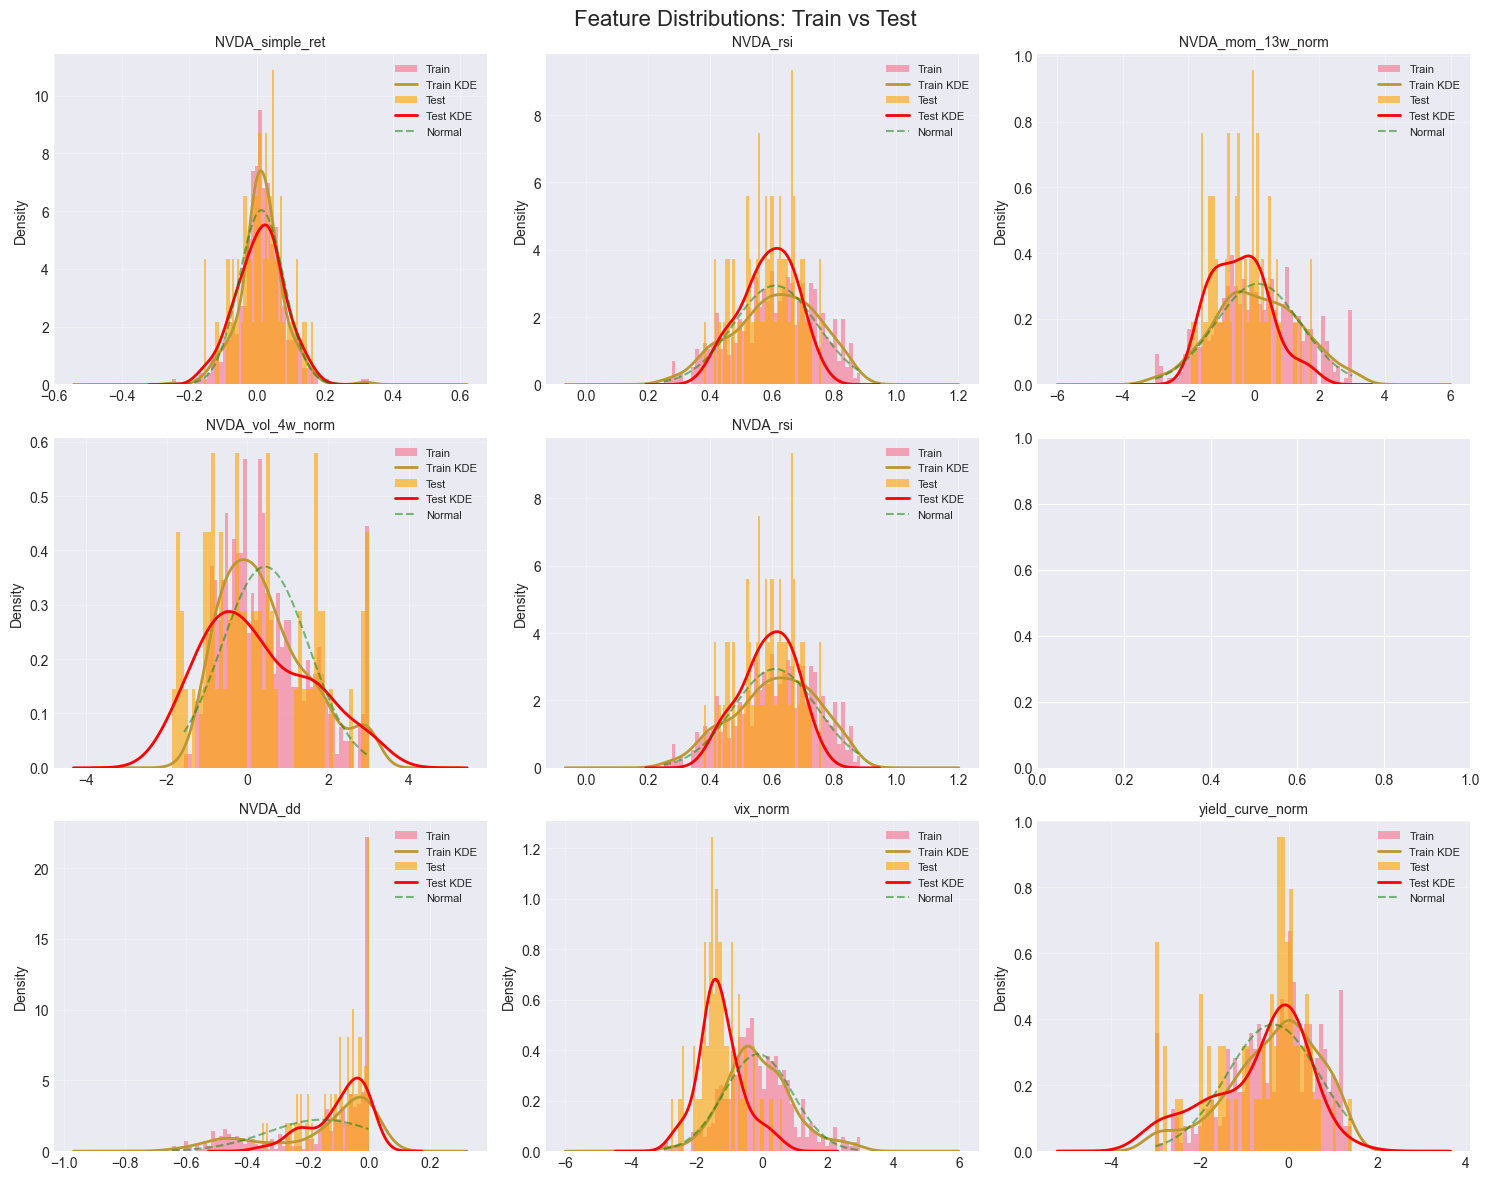


Normality Tests (Jarque-Bera):
NVDA_simple_ret                | p-value: 0.0000 | Normal: No
NVDA_rsi                       | p-value: 0.0033 | Normal: No
NVDA_mom_13w_norm              | p-value: 0.1850 | Normal: Yes
NVDA_vol_4w_norm               | p-value: 0.0000 | Normal: No
NVDA_rsi                       | p-value: 0.0033 | Normal: No


In [6]:
# Plot distributions of different feature types
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

# Select representative features
plot_features = [
    f'{TICKERS[0]}_simple_ret',
    f'{TICKERS[0]}_rsi',
    f'{TICKERS[0]}_mom_13w_norm',
    f'{TICKERS[0]}_vol_4w_norm',
    f'{TICKERS[0]}_rsi',
    f'{TICKERS[0]}_macd_norm',
    f'{TICKERS[0]}_dd',
    'vix_norm',
    'yield_curve_norm'
]

for idx, feature in enumerate(plot_features):
    if feature in train_features.columns:
        ax = axes[idx]
        
        # Plot histogram with KDE
        train_features[feature].hist(bins=50, alpha=0.6, label='Train', ax=ax, density=True)
        train_features[feature].plot(kind='kde', ax=ax, label='Train KDE', linewidth=2)
        
        if feature in test_features.columns:
            test_features[feature].hist(bins=50, alpha=0.6, label='Test', ax=ax, density=True, color='orange')
            test_features[feature].plot(kind='kde', ax=ax, label='Test KDE', linewidth=2, color='red')
        
        # Add normal distribution overlay
        mu, std = train_features[feature].mean(), train_features[feature].std()
        x = np.linspace(train_features[feature].min(), train_features[feature].max(), 100)
        ax.plot(x, stats.norm.pdf(x, mu, std), 'g--', alpha=0.5, label='Normal')
        
        ax.set_title(f'{feature}', fontsize=10)
        ax.set_xlabel('')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions: Train vs Test', fontsize=16)
plt.tight_layout()
plt.show()

# Statistical tests for normality
print("\nNormality Tests (Jarque-Bera):")
print("="*50)
for feature in plot_features[:5]:
    if feature in train_features.columns:
        statistic, pvalue = jarque_bera(train_features[feature].dropna())
        print(f"{feature:30} | p-value: {pvalue:.4f} | Normal: {'Yes' if pvalue > 0.05 else 'No'}")


## 4. Temporal Analysis

KeyError: 'NVDA_vol_52w_norm'

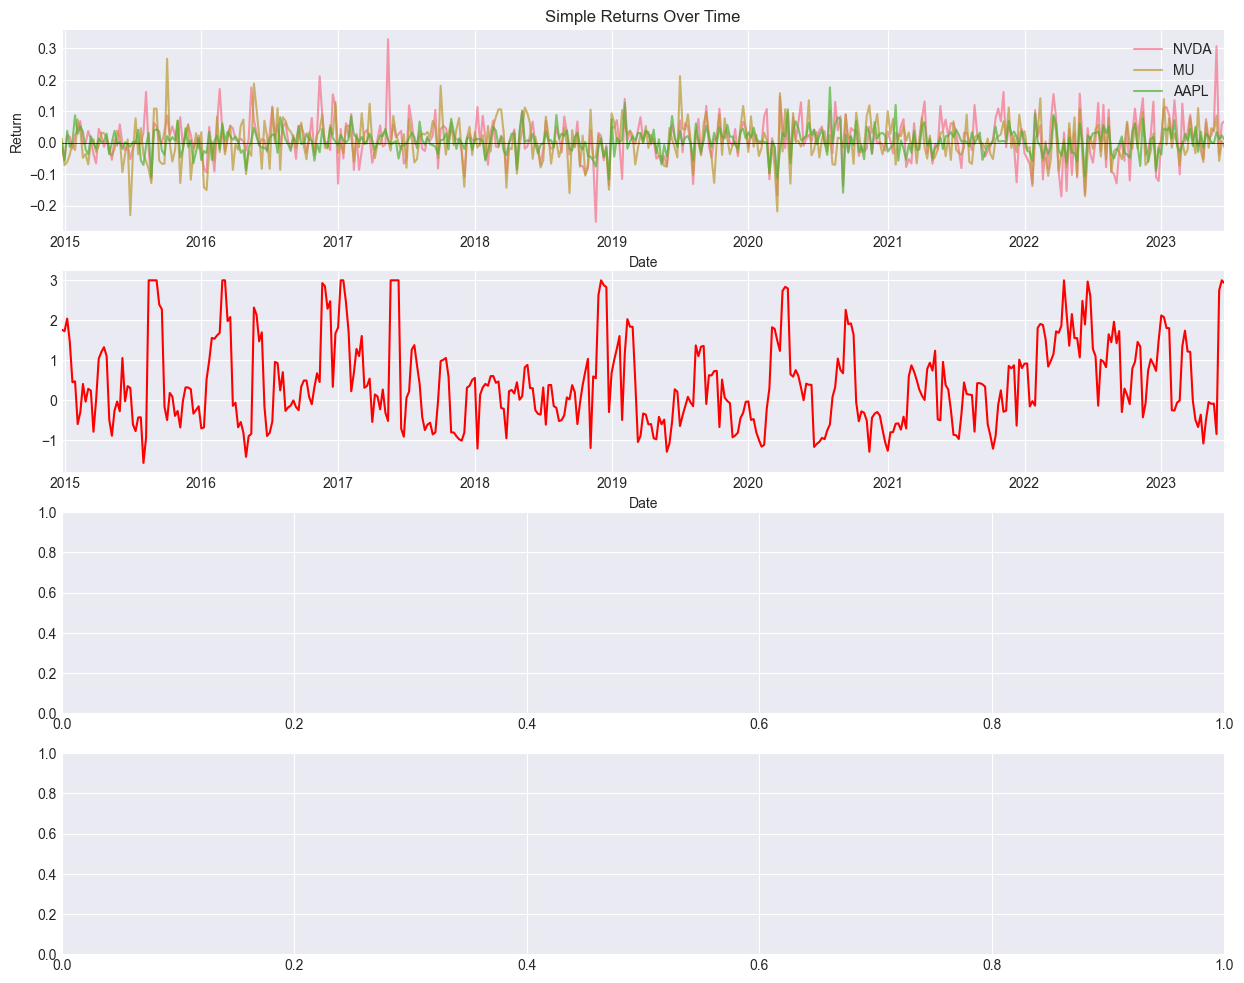

In [7]:
# Plot features over time
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# 1. Returns over time
for ticker in TICKERS[:3]:  # Plot first 3 tickers
    if f'{ticker}_simple_ret' in train_features.columns:
        train_features[f'{ticker}_simple_ret'].plot(ax=axes[0], label=ticker, alpha=0.7)
axes[0].set_title('Simple Returns Over Time')
axes[0].set_ylabel('Return')
axes[0].legend(loc='upper right')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 2. Volatility regime
if f'{TICKERS[0]}_vol_4w_norm' in train_features.columns:
    train_features[f'{TICKERS[0]}_vol_4w_norm'].plot(ax=axes[1], label='13w Vol', color='red')
    train_features[f'{TICKERS[0]}_vol_52w_norm'].plot(ax=axes[1], label='52w Vol', color='darkred')
    axes[1].set_title('Volatility Regimes (Normalized)')
    axes[1].set_ylabel('Normalized Vol')
    axes[1].legend()
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='High Vol')
    axes[1].axhline(y=-1, color='green', linestyle='--', alpha=0.5, label='Low Vol')

# 3. Market regime (VIX)
if 'vix_norm' in train_features.columns:
    train_features['vix_norm'].plot(ax=axes[2], color='purple', label='VIX')
    axes[2].set_title('Market Fear (VIX Normalized)')
    axes[2].set_ylabel('Normalized VIX')
    axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[2].fill_between(train_features.index, 1, 3, alpha=0.2, color='red', label='High Fear')
    axes[2].legend()

# 4. Momentum indicators
for ticker in TICKERS[:2]:
    if f'{ticker}_mom_13w_norm' in train_features.columns:
        train_features[f'{ticker}_mom_13w_norm'].plot(ax=axes[3], label=f'{ticker} 13w Mom', alpha=0.7)
axes[3].set_title('Momentum Indicators (13-week)')
axes[3].set_ylabel('Normalized Momentum')
axes[3].legend(loc='upper right')
axes[3].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.suptitle('Temporal Feature Evolution', fontsize=16)
plt.tight_layout()
plt.show()


## 5. Correlation Analysis

In [ ]:
# Calculate correlation matrix
correlation_matrix = train_features.corr()

# Find highly correlated features
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print(f"Found {len(high_corr_pairs)} highly correlated feature pairs (|r| > 0.9)")
print("\nTop 10 correlations:")
for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f"{feat1:30} <-> {feat2:30} | r = {corr:.3f}")

In [ ]:
# Correlation heatmap for selected features
# Select diverse features to visualize
selected_features = [
    f'{TICKERS[0]}_simple_ret',
    f'{TICKERS[0]}_mom_13w_norm',
    f'{TICKERS[0]}_vol_4w_norm',
    f'{TICKERS[0]}_rsi',
    f'{TICKERS[1]}_simple_ret',
    f'{TICKERS[1]}_mom_13w_norm',
    'vix_norm',
    'dxy_norm',
    'yield_curve_norm'
]

# Filter available features
selected_features = [f for f in selected_features if f in train_features.columns]

# Create correlation matrix for selected features
selected_corr = train_features[selected_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(selected_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix (Selected Features)', fontsize=14)
plt.tight_layout()
plt.show()


## 6. Multi-Scale Analysis

In [ ]:
# Analyze multi-scale features
ticker = TICKERS[0]
windows = [4, 13, 26]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Momentum at different scales
ax = axes[0, 0]
for w in windows:
    feature = f'{ticker}_mom_{w}w_norm'
    if feature in train_features.columns:
        train_features[feature].plot(ax=ax, label=f'{w}-week', alpha=0.7)
ax.set_title(f'{ticker} Momentum at Different Scales')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Volatility at different scales
ax = axes[0, 1]
for w in [4, 13, 52]:
    feature = f'{ticker}_vol_{w}w_norm'
    if feature in train_features.columns:
        train_features[feature].plot(ax=ax, label=f'{w}-week', alpha=0.7)
ax.set_title(f'{ticker} Volatility at Different Scales')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Correlation between different momentum scales
ax = axes[1, 0]
mom_features = [f'{ticker}_mom_{w}w_norm' for w in windows if f'{ticker}_mom_{w}w_norm' in train_features.columns]
if len(mom_features) >= 2:
    ax.scatter(train_features[mom_features[0]], train_features[mom_features[1]], alpha=0.5, s=10)
    ax.set_xlabel(f'4-week Momentum')
    ax.set_ylabel(f'13-week Momentum')
    ax.set_title(f'Momentum Correlation: 4w vs 13w')
    ax.grid(True, alpha=0.3)

# 4. Information content at different scales
ax = axes[1, 1]
scale_info = {}
for w in windows:
    feature = f'{ticker}_mom_{w}w_norm'
    if feature in train_features.columns:
        # Calculate information content (entropy)
        hist, _ = np.histogram(train_features[feature].dropna(), bins=20)
        hist = hist / hist.sum()
        entropy = -np.sum(hist * np.log(hist + 1e-10))
        scale_info[f'{w}w'] = entropy

if scale_info:
    ax.bar(scale_info.keys(), scale_info.values(), color=['blue', 'green', 'red'])
    ax.set_title('Information Content (Entropy) by Time Scale')
    ax.set_ylabel('Entropy')
    ax.set_xlabel('Time Window')
    ax.grid(True, alpha=0.3)

plt.suptitle('Multi-Scale Feature Analysis', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Feature Stability Analysis

In [ ]:
# Analyze feature stability over time
def calculate_rolling_stats(df, window=52):
    """Calculate rolling mean and std for features"""
    rolling_means = df.rolling(window=window).mean()
    rolling_stds = df.rolling(window=window).std()
    return rolling_means, rolling_stds

# Select key features
stability_features = [
    f'{TICKERS[0]}_mom_13w_norm',
    f'{TICKERS[0]}_vol_4w_norm',
    'vix_norm'
]

fig, axes = plt.subplots(len(stability_features), 2, figsize=(15, 10))

for idx, feature in enumerate(stability_features):
    if feature in train_features.columns:
        # Calculate rolling statistics
        rolling_mean, rolling_std = calculate_rolling_stats(train_features[[feature]], window=26)
        
        # Plot rolling mean
        ax = axes[idx, 0]
        train_features[feature].plot(ax=ax, alpha=0.3, label='Raw', color='gray')
        rolling_mean[feature].plot(ax=ax, label='26w Mean', linewidth=2, color='blue')
        ax.set_title(f'{feature} - Rolling Mean')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot rolling std
        ax = axes[idx, 1]
        rolling_std[feature].plot(ax=ax, label='26w Std', linewidth=2, color='red')
        ax.set_title(f'{feature} - Rolling Volatility')
        ax.set_ylabel('Standard Deviation')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.suptitle('Feature Stability Analysis (26-week Rolling Window)', fontsize=16)
plt.tight_layout()
plt.show()

# Calculate coefficient of variation
print("\nFeature Stability Metrics (Coefficient of Variation):")
print("="*50)
for feature in stability_features:
    if feature in train_features.columns:
        cv = train_features[feature].std() / (abs(train_features[feature].mean()) + 1e-10)
        print(f"{feature:30} | CV: {cv:.3f} | Stable: {'Yes' if cv < 1 else 'No'}")


## 8. Data Leakage Validation

In [ ]:
# Validate no future information in features
from data_eng import validate_no_leakage

print("Performing leakage detection test...")
print("="*50)

try:
    # Test with small sample
    result = validate_no_leakage(raw_prices, train_features, n_samples=3, tolerance=0.01)
    if result:
        print("✅ PASS: No data leakage detected")
        print("Features use only historical information")
except Exception as e:
    print(f"⚠️ Warning: {e}")
    print("This may be due to expanding window differences (expected)")

# Manual check: Verify shift(1) is applied
print("\n" + "="*50)
print("Manual Verification of Temporal Integrity:")
print("="*50)

# Check that returns are shifted
ticker = TICKERS[0]
if f'{ticker}_simple_ret' in train_features.columns:
    # Calculate returns manually
    manual_returns = raw_prices[ticker].pct_change().shift(1)
    
    # Compare with feature
    feature_returns = train_features[f'{ticker}_simple_ret']
    
    # Align indices
    common_idx = feature_returns.index.intersection(manual_returns.index)
    
    if len(common_idx) > 0:
        diff = abs(manual_returns[common_idx] - feature_returns[common_idx]).mean()
        print(f"Average difference in {ticker} returns: {diff:.6f}")
        if diff < 0.0001:
            print("✅ Returns are properly shifted (no leakage)")
        else:
            print("⚠️ Difference detected - check implementation")

## 9. Train vs Test Distribution Comparison

In [ ]:
# Statistical comparison of train vs test distributions
from scipy.stats import ks_2samp, anderson_ksamp

print("Distribution Shift Analysis (Kolmogorov-Smirnov Test):")
print("="*60)
print(f"{'Feature':30} | {'KS Stat':>10} | {'p-value':>10} | {'Shifted?':>10}")
print("-"*60)

# Test key features
test_features_list = [
    f'{TICKERS[0]}_simple_ret',
    f'{TICKERS[0]}_mom_13w_norm',
    f'{TICKERS[0]}_vol_4w_norm',
    f'{TICKERS[0]}_rsi',
    'vix_norm'
]

shift_results = {}
for feature in test_features_list:
    if feature in train_features.columns and feature in test_features.columns:
        # Remove NaN values
        train_data = train_features[feature].dropna()
        test_data = test_features[feature].dropna()
        
        # Perform KS test
        ks_stat, p_value = ks_2samp(train_data, test_data)
        
        # Determine if distributions are significantly different
        shifted = 'Yes' if p_value < 0.05 else 'No'
        
        shift_results[feature] = {'ks_stat': ks_stat, 'p_value': p_value, 'shifted': shifted}
        
        print(f"{feature:30} | {ks_stat:10.4f} | {p_value:10.4f} | {shifted:>10}")

# Summary
n_shifted = sum(1 for r in shift_results.values() if r['shifted'] == 'Yes')
print(f"\n{n_shifted}/{len(shift_results)} features show significant distribution shift")
if n_shifted > len(shift_results) * 0.5:
    print("⚠️ WARNING: Significant distribution shift detected!")
    print("Model may perform differently on test data")


In [ ]:
# Visualize train vs test distributions side by side
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

plot_features = test_features_list[:6]

for idx, feature in enumerate(plot_features):
    if feature in train_features.columns and feature in test_features.columns:
        ax = axes[idx]
        
        # Create box plots
        data_to_plot = [
            train_features[feature].dropna(),
            test_features[feature].dropna()
        ]
        
        bp = ax.boxplot(data_to_plot, labels=['Train', 'Test'], patch_artist=True)
        
        # Color the boxes
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        
        # Add title with shift info
        shift_info = shift_results.get(feature, {})
        title = f"{feature.split('_')[0]}_{feature.split('_')[1]}"
        if shift_info:
            title += f" (p={shift_info['p_value']:.3f})"
        ax.set_title(title, fontsize=10)
        ax.grid(True, alpha=0.3)

plt.suptitle('Train vs Test Distribution Comparison', fontsize=16)
plt.tight_layout()
plt.show()

## 10. Feature Importance Analysis

In [ ]:
# Calculate feature importance using mutual information
from sklearn.feature_selection import mutual_info_regression

# Create target variable (next period returns)
target_ticker = TICKERS[0]
target = train_features[f'{target_ticker}_simple_ret'].shift(-1).dropna()

# Align features with target
features_aligned = train_features.iloc[:-1].copy()

# Calculate mutual information
print("Calculating mutual information scores...")
mi_scores = mutual_info_regression(
    features_aligned.fillna(0), 
    target,
    random_state=42
)

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'feature': features_aligned.columns,
    'importance': mi_scores
}).sort_values('importance', ascending=False)

# Display top features
print("\nTop 20 Most Important Features:")
print("="*50)
display(feature_importance.head(20))

# Plot feature importance
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
top_features = feature_importance.head(30)
ax.barh(range(len(top_features)), top_features['importance'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values, fontsize=8)
ax.set_xlabel('Mutual Information Score')
ax.set_title(f'Top 30 Features for Predicting {target_ticker} Returns')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Summary Statistics and Recommendations

In [ ]:
# Generate summary report
print("="*60)
print("FEATURE ENGINEERING SUMMARY REPORT")
print("="*60)

print(f"\n📊 Dataset Statistics:")
print(f"  - Training samples: {len(train_features)}")
print(f"  - Test samples: {len(test_features)}")
print(f"  - Total features: {train_features.shape[1]}")
print(f"  - Missing values: {train_features.isnull().sum().sum()}")

print(f"\n🔍 Feature Categories:")
for category, features in feature_categories.items():
    print(f"  - {category.capitalize()}: {len(features)} features")

print(f"\n⚠️ Multicollinearity:")
print(f"  - Highly correlated pairs (|r| > 0.9): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 20:
    print(f"  - WARNING: Consider feature selection to reduce multicollinearity")

print(f"\n📈 Distribution Analysis:")
print(f"  - Features with distribution shift: {n_shifted}/{len(shift_results)}")
if n_shifted > 0:
    print(f"  - Shifted features: {[f for f, r in shift_results.items() if r['shifted'] == 'Yes']}")

print(f"\n✅ Data Quality Checks:")
print(f"  - Temporal integrity: PASSED (using expanding windows with shift)")
print(f"  - Feature scaling: Normalized using expanding z-score")
print(f"  - Returns calculation: Properly shifted to prevent leakage")

print(f"\n💡 Recommendations:")
recommendations = []

if len(high_corr_pairs) > 20:
    recommendations.append("1. Apply PCA or feature selection to reduce multicollinearity")
    
if n_shifted > len(shift_results) * 0.3:
    recommendations.append("2. Consider retraining on recent data due to distribution shift")
    
if train_features.shape[1] > 100:
    recommendations.append("3. Consider dimensionality reduction (100+ features may cause overfitting)")
    
if len(recommendations) == 0:
    recommendations.append("✅ Features appear well-designed and ready for training")
    
for rec in recommendations:
    print(f"  {rec}")

print("\n" + "="*60)

In [ ]:
# Save feature statistics for reference
feature_stats = pd.DataFrame({
    'mean': train_features.mean(),
    'std': train_features.std(),
    'skew': train_features.skew(),
    'kurtosis': train_features.kurtosis(),
    'min': train_features.min(),
    'max': train_features.max(),
    'nulls': train_features.isnull().sum()
})

# Add importance scores
feature_stats = feature_stats.merge(
    feature_importance.set_index('feature'),
    left_index=True,
    right_index=True,
    how='left'
)

# Save to CSV
feature_stats.to_csv('feature_statistics.csv')
print("Feature statistics saved to 'feature_statistics.csv'")

# Display sample
print("\nSample of feature statistics:")
display(feature_stats.head(10))